# Cold-Start Analysis

This notebook loads cold-start result sessions for RPG and SASRec from both the shared group artifacts tree and the repo-local artifacts tree, then builds reporting tables and plots for the latest available run of each dataset, model, and config track.

Expected layouts:

```text
<artifact-root>/<track>/<dataset>/<session>/tables/cold_start_summary.json
<artifact-root>/<session>/tables/cold_start_summary.json
```

The second form is the older single-session layout and is labeled `legacy` in the tables below.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

ROOT = Path.cwd().resolve()
while ROOT.name not in {"RPG", "RPG-uva"} and ROOT.parent != ROOT:
    ROOT = ROOT.parent

ARTIFACT_SOURCES = [
    {
        "model": "RPG",
        "root": Path("/projects/prjs2120/groups/group_16/artifacts/rpg/cold_start"),
    },
    {
        "model": "RPG",
        "root": ROOT / "artifacts" / "rpg" / "cold_start",
    },
    {
        "model": "SASRec",
        "root": Path("/projects/prjs2120/groups/group_16/artifacts/sasrec/cold_start"),
    },
    {
        "model": "SASRec",
        "root": ROOT / "artifacts" / "sasrec" / "cold_start",
    },
]

seen_sources = set()
ARTIFACT_SOURCES = [
    source
    for source in ARTIFACT_SOURCES
    if (source["model"], source["root"]) not in seen_sources
    and not seen_sources.add((source["model"], source["root"]))
]

METRIC_ORDER = ["recall@5", "ndcg@5", "recall@10", "ndcg@10"]
PRIMARY_METRIC = "ndcg@10"
TRACK_LABELS = {
    "released_readme": "released README",
    "paper_appendix": "paper appendix",
    "legacy": "legacy",
}
DATASET_LABELS = {
    "Sports_and_Outdoors": "Sports",
    "sports_and_outdoors": "Sports",
    "Beauty": "Beauty",
    "beauty": "Beauty",
    "Toys_and_Games": "Toys",
    "toys_and_games": "Toys",
    "CDs_and_Vinyl": "CDs",
    "cds_and_vinyl": "CDs",
}
DATASET_ORDER = ["Sports", "Beauty", "Toys", "CDs"]
MODEL_ORDER = ["RPG", "SASRec"]
TRACK_ORDER = ["released README", "paper appendix", "legacy"]
EXCLUDED_MODEL_TRACKS = {("RPG", "legacy")}


In [2]:
def _dataset_label(raw_value: str | None) -> str:
    if raw_value is None:
        return "Unknown"
    return DATASET_LABELS.get(raw_value, raw_value)


def _track_label(raw_value: str) -> str:
    return TRACK_LABELS.get(raw_value, raw_value)


def _model_label(payload: dict, source_model: str) -> str:
    raw_model = str(payload.get("model") or source_model)
    if raw_model.lower().startswith("sasrec"):
        return "SASRec"
    if raw_model.upper() == "RPG":
        return "RPG"
    return raw_model


def _ordered(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    if frame.empty:
        return frame
    sort_frame = frame.copy()
    sort_frame["_model_rank"] = sort_frame["model"].map({name: idx for idx, name in enumerate(MODEL_ORDER)}).fillna(len(MODEL_ORDER))
    sort_frame["_dataset_rank"] = sort_frame["dataset"].map({name: idx for idx, name in enumerate(DATASET_ORDER)}).fillna(len(DATASET_ORDER))
    sort_frame["_track_rank"] = sort_frame["track_label"].map({name: idx for idx, name in enumerate(TRACK_ORDER)}).fillna(len(TRACK_ORDER))
    sort_columns = ["_dataset_rank", "_model_rank", "_track_rank"] + columns
    return sort_frame.sort_values(sort_columns).drop(columns=["_model_rank", "_dataset_rank", "_track_rank"]).reset_index(drop=True)


def _parse_summary(summary_path: Path, artifact_root: Path, source_model: str) -> tuple[dict, list[dict]]:
    payload = json.loads(summary_path.read_text())
    session_root = summary_path.parents[1]
    relative_parts = summary_path.relative_to(artifact_root).parts

    if len(relative_parts) >= 5 and relative_parts[-2] == "tables":
        track = relative_parts[0]
        dataset_slug = relative_parts[1]
        session = relative_parts[2]
    else:
        track = "legacy"
        dataset_slug = payload.get("category") or payload.get("dataset") or "unknown"
        session = session_root.name

    model = _model_label(payload, source_model)
    dataset = _dataset_label(payload.get("category") or dataset_slug)
    overall_results = payload.get("overall_results", {})
    group_rows = payload.get("group_rows", [])
    checkpoint_path = payload.get("checkpoint_path")
    row = {
        "model": model,
        "artifact_root": str(artifact_root),
        "summary_path": str(summary_path),
        "session_root": str(session_root),
        "session": session,
        "track": track,
        "track_label": _track_label(track),
        "dataset_slug": dataset_slug,
        "dataset": dataset,
        "category": payload.get("category"),
        "bucket_spec": payload.get("bucket_spec"),
        "checkpoint_path": checkpoint_path,
        "checkpoint_name": None if checkpoint_path is None else Path(checkpoint_path).name,
        "plot_metric": payload.get("plot_metric"),
    }
    for metric_name in METRIC_ORDER:
        row[metric_name] = overall_results.get(metric_name)
    row["n_buckets"] = len(group_rows)

    bucket_rows = []
    for bucket in group_rows:
        bucket_row = {
            "model": model,
            "artifact_root": str(artifact_root),
            "summary_path": str(summary_path),
            "session_root": str(session_root),
            "session": session,
            "track": track,
            "track_label": _track_label(track),
            "dataset_slug": dataset_slug,
            "dataset": dataset,
            "bucket_label": bucket.get("bucket_label"),
            "bucket_range": bucket.get("bucket_range"),
            "bucket_min_count": bucket.get("bucket_min_count"),
            "bucket_max_count": bucket.get("bucket_max_count"),
            "n_examples": bucket.get("n_examples", 0),
        }
        for metric_name in METRIC_ORDER + ["n_visited_items"]:
            bucket_row[metric_name] = bucket.get(metric_name)
        bucket_rows.append(bucket_row)
    return row, bucket_rows


run_rows = []
bucket_rows = []
for source in ARTIFACT_SOURCES:
    artifact_root = source["root"]
    if not artifact_root.exists():
        continue
    for summary_path in sorted(artifact_root.rglob("cold_start_summary.json")):
        parsed_run, parsed_buckets = _parse_summary(summary_path, artifact_root, source["model"])
        run_rows.append(parsed_run)
        bucket_rows.extend(parsed_buckets)

all_runs = pd.DataFrame(run_rows)
all_buckets = pd.DataFrame(bucket_rows)

def _drop_excluded_model_tracks(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame
    excluded = frame.apply(lambda row: (row["model"], row["track"]) in EXCLUDED_MODEL_TRACKS, axis=1)
    return frame.loc[~excluded].reset_index(drop=True)

all_runs = _drop_excluded_model_tracks(all_runs)
all_buckets = _drop_excluded_model_tracks(all_buckets)

if all_runs.empty:
    joined_roots = "\n".join(f"{source['model']}: {source['root']}" for source in ARTIFACT_SOURCES)
    print(f"No cold_start_summary.json files found under:\n{joined_roots}")
    latest_runs = pd.DataFrame()
    latest_buckets = pd.DataFrame()
else:
    latest_runs = (
        all_runs.sort_values(["model", "dataset", "track", "session"])
        .groupby(["model", "dataset", "track"], as_index=False)
        .tail(1)
        .reset_index(drop=True)
    )
    latest_keys = latest_runs[["model", "dataset", "track", "session"]]
    latest_buckets = all_buckets.merge(latest_keys, on=["model", "dataset", "track", "session"], how="inner")
    latest_runs = _ordered(latest_runs, ["session"])
    latest_buckets = _ordered(latest_buckets, ["bucket_min_count", "session"])

print(f"Discovered {len(all_runs)} cold-start runs across {sum(source['root'].exists() for source in ARTIFACT_SOURCES)} artifact roots.")


Discovered 8 cold-start runs across 2 artifact roots.


## Table 1: Latest Run Overview

This table keeps one latest session per `(model, dataset, track)` tuple and shows the overall cold-start metrics stored in the summary payload.


In [3]:
if latest_runs.empty:
    print("No cold-start runs available.")
else:
    overview = latest_runs[
        [
            "model",
            "dataset",
            "track_label",
            "session",
            "bucket_spec",
            "recall@5",
            "ndcg@5",
            "recall@10",
            "ndcg@10",
            "checkpoint_name",
            "artifact_root",
        ]
    ].copy()
    overview = overview.rename(columns={"track_label": "track"})
    display(overview)


,model,dataset,track,session,bucket_spec,recall@5,ndcg@5,recall@10,ndcg@10,checkpoint_name,artifact_root
0,RPG,Sports,released README,20260610T154132050775Z_job23641324,"0-5,6-10,11-15,16-20",0.029721,0.020780,0.044328,0.025482,rpg_repro_sports_and_outdoors-scripts|rpg.py_-...,/gpfs/home6/scur1202/RPG/artifacts/rpg/cold_start
1,SASRec,Sports,released README,20260611T185503345648Z_job23690177,"0-5,6-10,11-15,16-20",0.019186,0.012738,0.031153,0.016595,sasrec_modernized_sports_and_outdoors.pt,/gpfs/home6/scur1202/RPG/artifacts/sasrec/cold...
2,RPG,Beauty,released README,20260610T154350059788Z_job23642074,"0-5,6-10,11-15,16-20",0.054286,0.037750,0.078478,0.045563,rpg_repro_beauty-scripts|rpg.py_--preset_beaut...,/gpfs/home6/scur1202/RPG/artifacts/rpg/cold_start
3,SASRec,Beauty,released README,20260611T194933743666Z_job23692000,"0-5,6-10,11-15,16-20",0.039574,0.025962,0.058981,0.032185,sasrec_modernized_beauty.pt,/gpfs/home6/scur1202/RPG/artifacts/sasrec/cold...
4,RPG,Toys,released README,20260610T154412858215Z_job23642075,"0-5,6-10,11-15,16-20",0.057799,0.039101,0.086184,0.048252,rpg_repro_toys_and_games-scripts|rpg.py_--pres...,/gpfs/home6/scur1202/RPG/artifacts/rpg/cold_start
5,SASRec,Toys,released README,20260611T195035422066Z_job23692028,"0-5,6-10,11-15,16-20",0.046054,0.030488,0.066814,0.037155,sasrec_modernized_toys_and_games.pt,/gpfs/home6/scur1202/RPG/artifacts/sasrec/cold...
6,RPG,CDs,released README,20260610T154422093427Z_job23642084,"0-5,6-10,11-15,16-20",0.050652,0.034350,0.074105,0.041906,rpg_repro_cds_and_vinyl-scripts|rpg.py_--prese...,/gpfs/home6/scur1202/RPG/artifacts/rpg/cold_start
7,SASRec,CDs,released README,20260612T171427662944Z_job23732813,"0-5,6-10,11-15,16-20",0.031718,0.020282,0.051051,0.026518,sasrec_modernized_cds_and_vinyl.pt,/gpfs/home6/scur1202/RPG/artifacts/sasrec/cold...


## Table 2: Bucket-Level Metrics

The first table pivots the primary metric by training-frequency bucket. The second table shows how many test examples fall into each bucket.


In [4]:
if latest_buckets.empty:
    print("No bucket-level rows available.")
else:
    metric_table = latest_buckets.pivot_table(
        index=["model", "dataset", "track_label"],
        columns="bucket_range",
        values=PRIMARY_METRIC,
        aggfunc="first",
    )
    metric_table = _ordered(metric_table.reset_index(), [])
    metric_table = metric_table.rename(columns={"track_label": "track"})
    print(f"Primary metric by bucket: {PRIMARY_METRIC}")
    display(metric_table)

    count_table = latest_buckets.pivot_table(
        index=["model", "dataset", "track_label"],
        columns="bucket_range",
        values="n_examples",
        aggfunc="first",
    )
    count_table = _ordered(count_table.reset_index(), [])
    count_table = count_table.rename(columns={"track_label": "track"})
    print("Test examples per bucket")
    print("Note: n_examples is determined by the dataset split and bucket boundaries, so it is expected to match across models for the same dataset.")
    display(count_table)


Primary metric by bucket: ndcg@10


bucket_range,model,dataset,track,"[0, 5]","[11, 15]","[16, 20]","[6, 10]"
0,RPG,Sports,released README,0.004514,0.017149,0.019908,0.012001
1,SASRec,Sports,released README,0.003305,0.006723,0.005865,0.004590
2,RPG,Beauty,released README,0.014827,0.040687,0.034003,0.020594
3,SASRec,Beauty,released README,0.010366,0.021203,0.025490,0.013123
4,RPG,Toys,released README,0.025242,0.061039,0.063975,0.037882
5,SASRec,Toys,released README,0.026314,0.043149,0.040139,0.029144
6,RPG,CDs,released README,0.001351,0.010876,0.016091,0.003736
7,SASRec,CDs,released README,0.004019,0.012728,0.017675,0.007906


Test examples per bucket
Note: n_examples is determined by the dataset split and bucket boundaries, so it is expected to match across models for the same dataset.


bucket_range,model,dataset,track,"[0, 5]","[11, 15]","[16, 20]","[6, 10]"
0,RPG,Sports,released README,9962,3794,2585,6816
1,SASRec,Sports,released README,9962,3794,2585,6816
2,RPG,Beauty,released README,6197,2538,1529,4261
3,SASRec,Beauty,released README,6197,2538,1529,4261
4,RPG,Toys,released README,6249,2226,1454,4011
5,SASRec,Toys,released README,6249,2226,1454,4011
6,RPG,CDs,released README,13139,7542,5754,12847
7,SASRec,CDs,released README,13139,7542,5754,12847


## Plot 1: Primary Metric by Bucket

This section emits one figure per dataset. Bars are grouped by reproduced model and config track.
If two models look identical here, the notebook outputs are likely stale and the plotting cells should be re-run from the top.


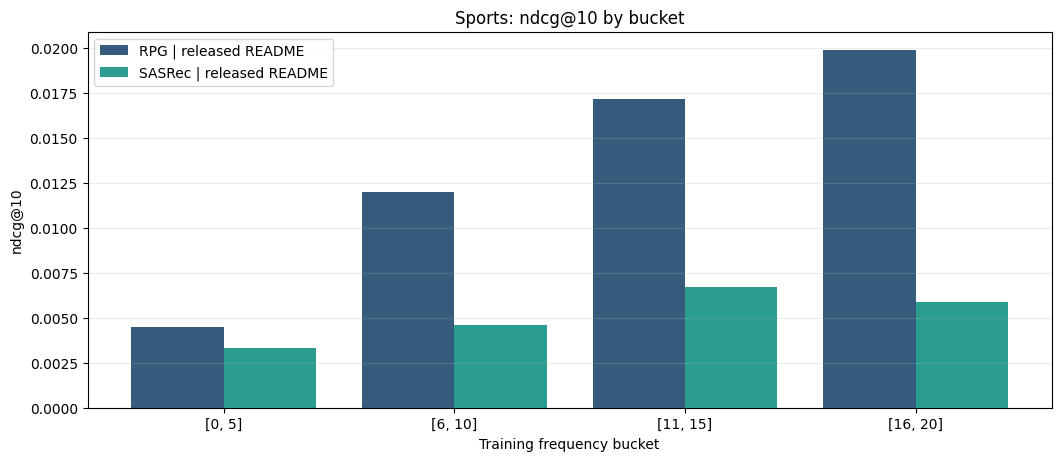

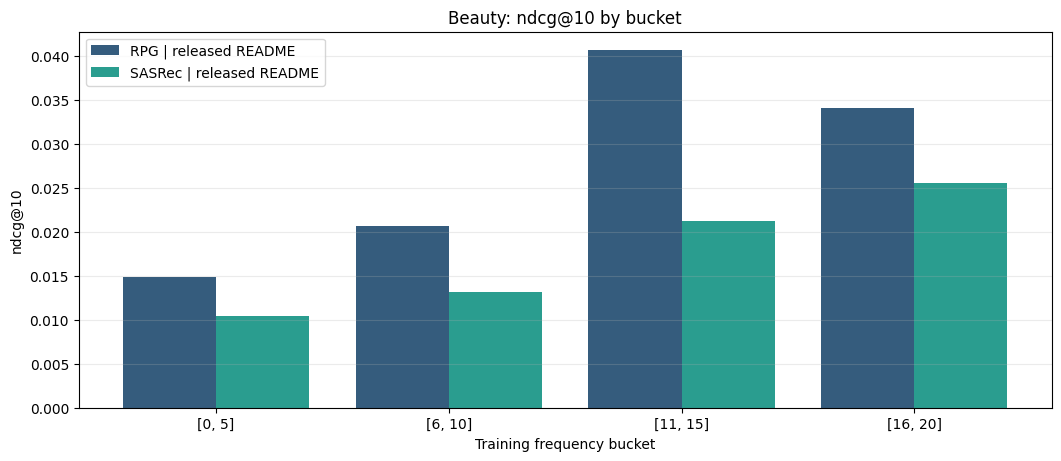

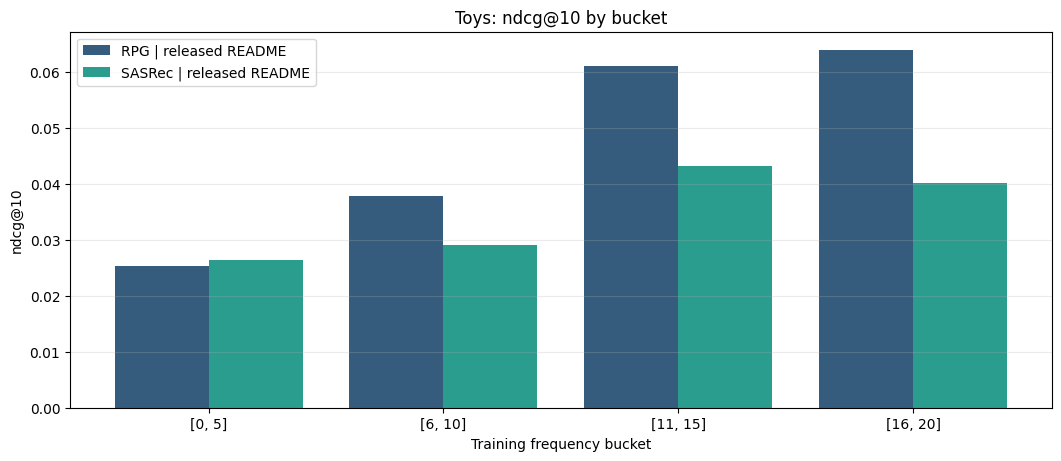

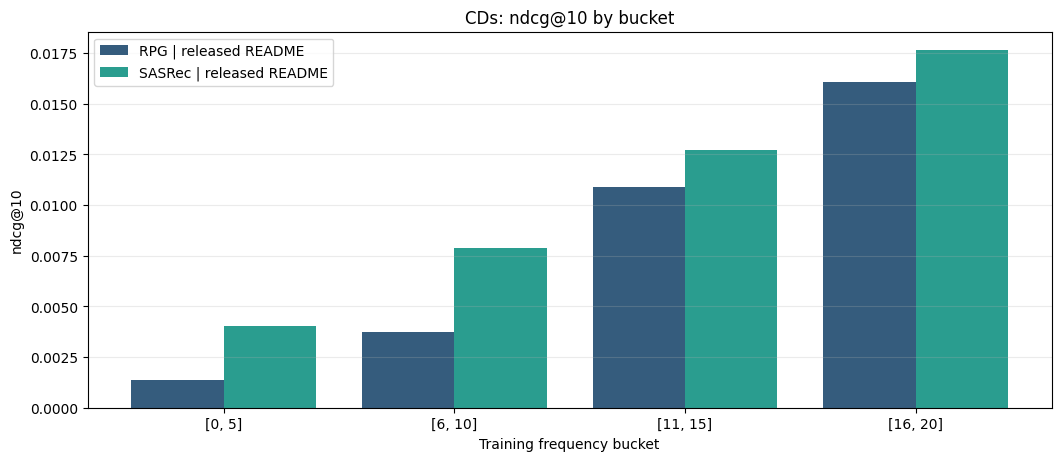

In [5]:
if latest_buckets.empty:
    print("No bucket-level rows available.")
else:
    datasets = [name for name in DATASET_ORDER if name in set(latest_buckets["dataset"])]
    if not datasets:
        datasets = sorted(set(latest_buckets["dataset"]))

    color_map = {
        "RPG | released README": "#355C7D",
        "RPG | paper appendix": "#C06C84",
        "SASRec | released README": "#2A9D8F",
        "SASRec | paper appendix": "#E9C46A",
        "SASRec | legacy": "#A8DADC",
    }

    for dataset in datasets:
        frame = latest_buckets[latest_buckets["dataset"] == dataset].copy()
        buckets = frame.sort_values("bucket_min_count")["bucket_range"].drop_duplicates().tolist()
        series = (
            frame[["model", "track_label"]]
            .drop_duplicates()
            .sort_values(["model", "track_label"], key=lambda col: col)
            .apply(lambda row: f"{row['model']} | {row['track_label']}", axis=1)
            .tolist()
        )
        series = [label for label in series if label.split(" | ")[0] in MODEL_ORDER]
        x = np.arange(len(buckets), dtype=float)
        width = 0.8 / max(len(series), 1)
        figure, axis = plt.subplots(figsize=(10.5, 4.5), constrained_layout=True)

        for index, label in enumerate(series):
            model, track = label.split(" | ", 1)
            series_frame = frame[(frame["model"] == model) & (frame["track_label"] == track)].sort_values("bucket_min_count")
            values = [
                float(series_frame.loc[series_frame["bucket_range"] == bucket, PRIMARY_METRIC].iloc[0])
                if not series_frame.loc[series_frame["bucket_range"] == bucket, PRIMARY_METRIC].empty
                else np.nan
                for bucket in buckets
            ]
            offsets = x - 0.4 + width / 2 + index * width
            axis.bar(offsets, values, width=width, label=label, color=color_map.get(label, None))

        axis.set_title(f"{dataset}: {PRIMARY_METRIC} by bucket")
        axis.set_xlabel("Training frequency bucket")
        axis.set_ylabel(PRIMARY_METRIC)
        axis.set_xticks(x)
        axis.set_xticklabels(buckets)
        axis.grid(axis="y", alpha=0.25)
        axis.set_ylim(bottom=0)
        axis.legend(loc="upper left")
        plt.show()


## Plot 2: Test Example Counts by Bucket

This section emits one figure per dataset and helps interpret whether a bucket-level metric is based on a large or small slice of the test set.
Because the bucketing is derived from the dataset split rather than the model, these bars should be identical across models for the same dataset.


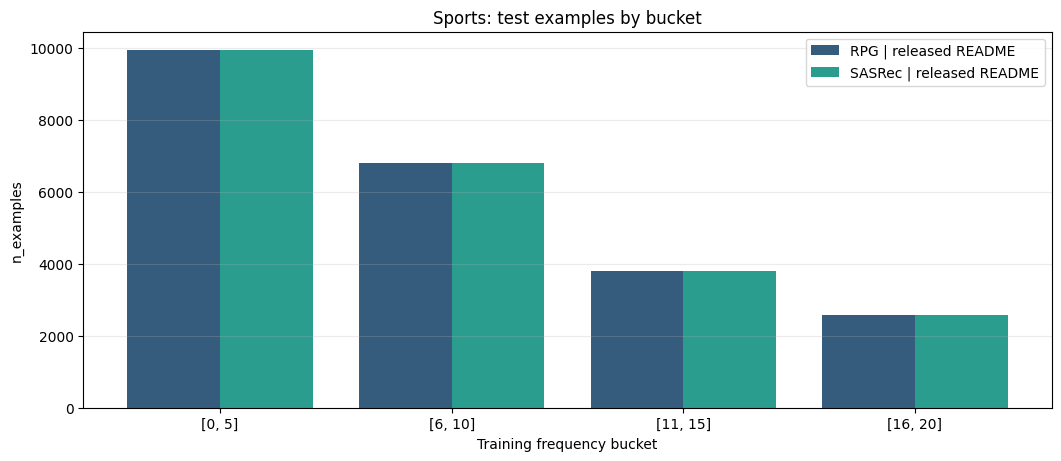

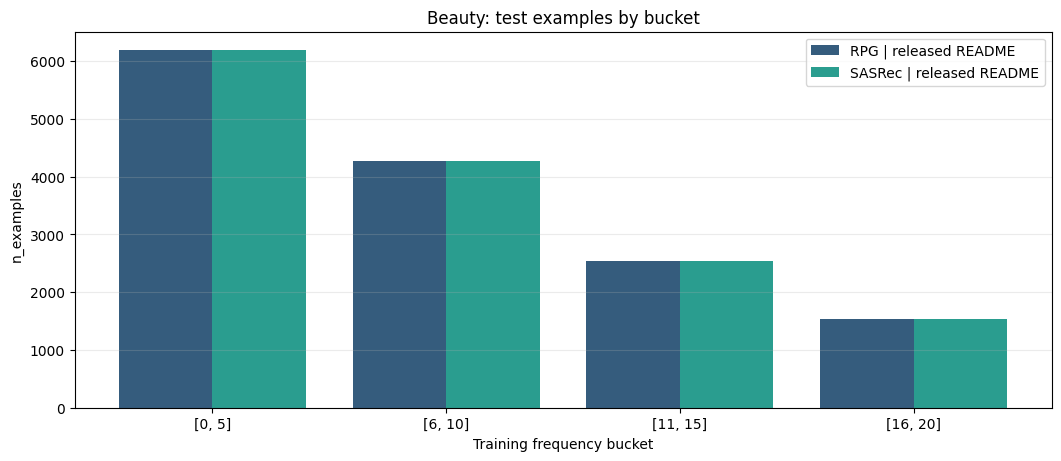

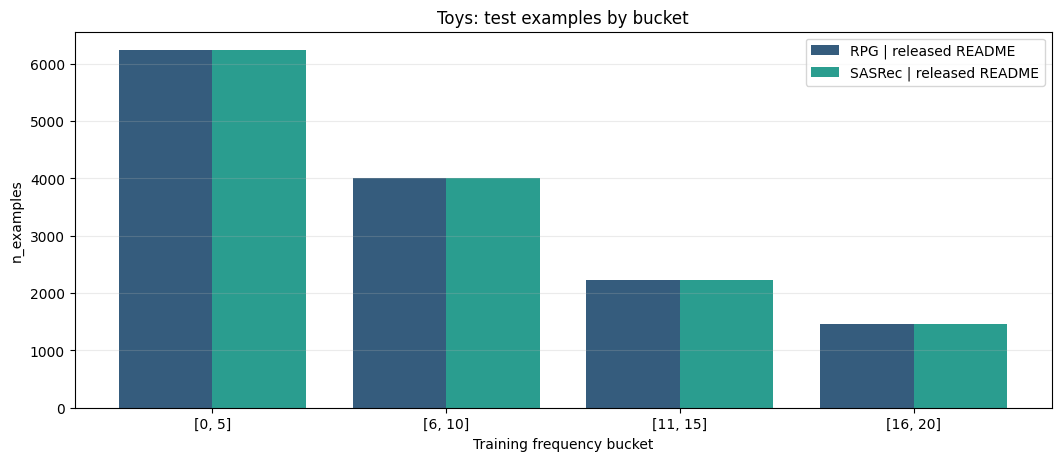

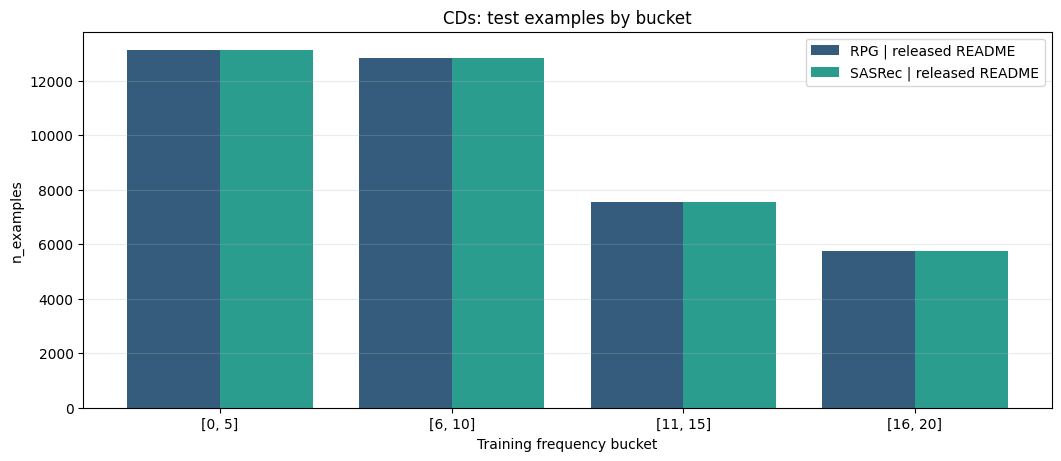

In [6]:
if latest_buckets.empty:
    print("No bucket-level rows available.")
else:
    datasets = [name for name in DATASET_ORDER if name in set(latest_buckets["dataset"])]
    if not datasets:
        datasets = sorted(set(latest_buckets["dataset"]))

    color_map = {
        "RPG | released README": "#355C7D",
        "RPG | paper appendix": "#C06C84",
        "SASRec | released README": "#2A9D8F",
        "SASRec | paper appendix": "#E9C46A",
        "SASRec | legacy": "#A8DADC",
    }

    for dataset in datasets:
        frame = latest_buckets[latest_buckets["dataset"] == dataset].copy()
        buckets = frame.sort_values("bucket_min_count")["bucket_range"].drop_duplicates().tolist()
        series = (
            frame[["model", "track_label"]]
            .drop_duplicates()
            .sort_values(["model", "track_label"], key=lambda col: col)
            .apply(lambda row: f"{row['model']} | {row['track_label']}", axis=1)
            .tolist()
        )
        x = np.arange(len(buckets), dtype=float)
        width = 0.8 / max(len(series), 1)
        figure, axis = plt.subplots(figsize=(10.5, 4.5), constrained_layout=True)

        for index, label in enumerate(series):
            model, track = label.split(" | ", 1)
            series_frame = frame[(frame["model"] == model) & (frame["track_label"] == track)].sort_values("bucket_min_count")
            values = [
                float(series_frame.loc[series_frame["bucket_range"] == bucket, "n_examples"].iloc[0])
                if not series_frame.loc[series_frame["bucket_range"] == bucket, "n_examples"].empty
                else np.nan
                for bucket in buckets
            ]
            offsets = x - 0.4 + width / 2 + index * width
            axis.bar(offsets, values, width=width, label=label, color=color_map.get(label, None))

        axis.set_title(f"{dataset}: test examples by bucket")
        axis.set_xlabel("Training frequency bucket")
        axis.set_ylabel("n_examples")
        axis.set_xticks(x)
        axis.set_xticklabels(buckets)
        axis.grid(axis="y", alpha=0.25)
        axis.legend(loc="upper right")
        plt.show()


## Paper Figure 5 Reproduction: Sports Cold Start

The paper's Figure 5 reports Sports `NDCG@10` across the four cold-start buckets. This cell reproduces that view for all available reproduced models.


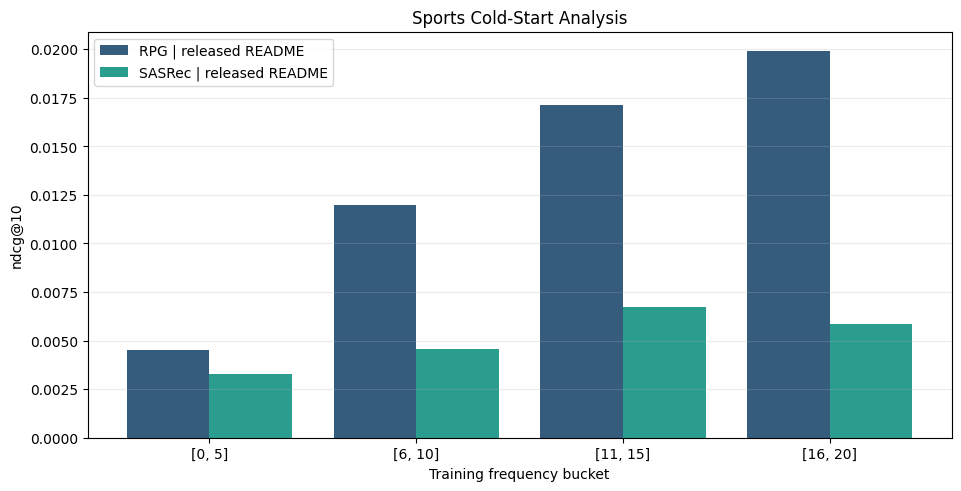

In [7]:
if latest_buckets.empty:
    print("No bucket-level rows available.")
else:
    sports = latest_buckets[latest_buckets["dataset"] == "Sports"].copy()
    if sports.empty:
        print("No Sports cold-start runs available.")
    else:
        buckets = sports.sort_values("bucket_min_count")["bucket_range"].drop_duplicates().tolist()
        series = (
            sports[["model", "track_label"]]
            .drop_duplicates()
            .sort_values(["model", "track_label"], key=lambda col: col)
            .apply(lambda row: f"{row['model']} | {row['track_label']}", axis=1)
            .tolist()
        )
        x = np.arange(len(buckets), dtype=float)
        width = 0.8 / max(len(series), 1)
        color_map = {
            "RPG | released README": "#355C7D",
            "RPG | paper appendix": "#C06C84",
            "SASRec | released README": "#2A9D8F",
            "SASRec | paper appendix": "#E9C46A",
            "SASRec | legacy": "#A8DADC",
        }

        fig, ax = plt.subplots(figsize=(9.5, 4.8), constrained_layout=True)
        for index, label in enumerate(series):
            model, track = label.split(" | ", 1)
            frame = sports[(sports["model"] == model) & (sports["track_label"] == track)].sort_values("bucket_min_count")
            values = [
                float(frame.loc[frame["bucket_range"] == bucket, PRIMARY_METRIC].iloc[0])
                if not frame.loc[frame["bucket_range"] == bucket, PRIMARY_METRIC].empty
                else np.nan
                for bucket in buckets
            ]
            offsets = x - 0.4 + width / 2 + index * width
            ax.bar(offsets, values, width=width, label=label, color=color_map.get(label, None))

        ax.set_title("Sports Cold-Start Analysis")
        ax.set_xlabel("Training frequency bucket")
        ax.set_ylabel(PRIMARY_METRIC)
        ax.set_xticks(x)
        ax.set_xticklabels(buckets)
        ax.grid(axis="y", alpha=0.25)
        ax.set_ylim(bottom=0)
        ax.legend(loc="upper left")
        plt.show()


## Plot 4: Cross-Dataset RPG vs SASRec Summary

This final section emits one dumbbell plot per dataset, then a combined multi-panel bar chart across all datasets.
Each row is one bucket within that dataset, the two markers show the RPG and SASRec values for the selected metric, and the connecting segment makes the gap between the models easy to scan.
The plots are limited to the shared `released README` track so the comparison stays like-for-like.


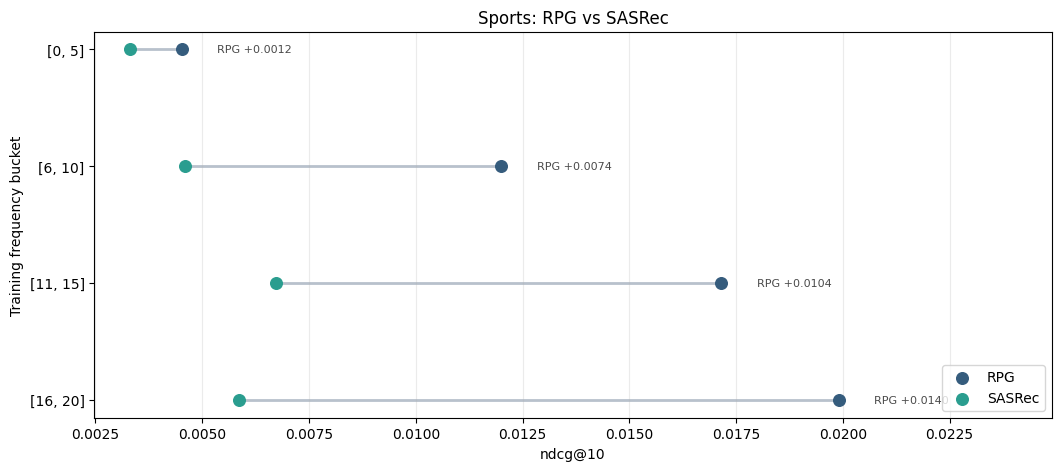

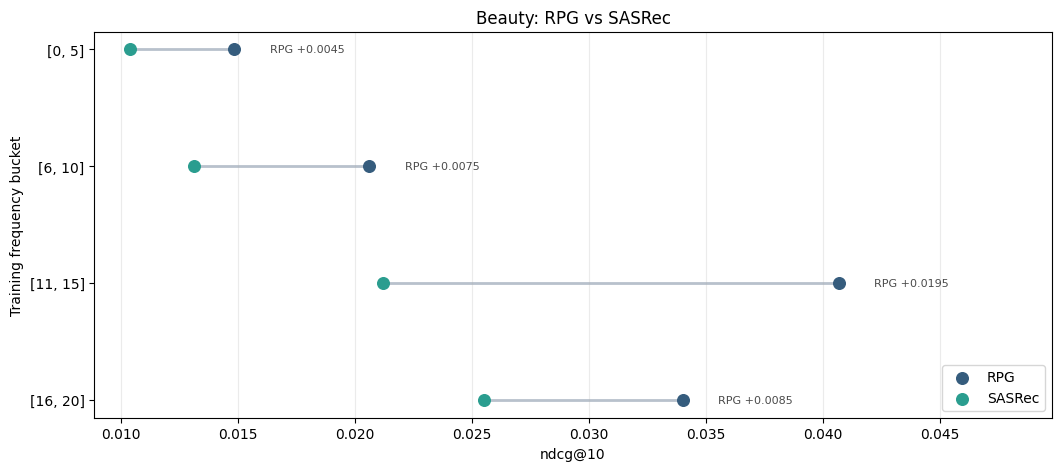

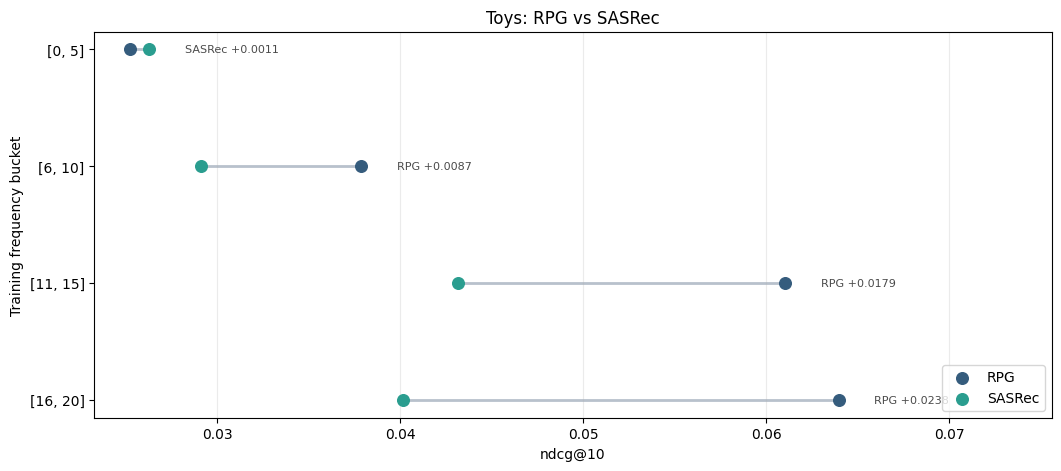

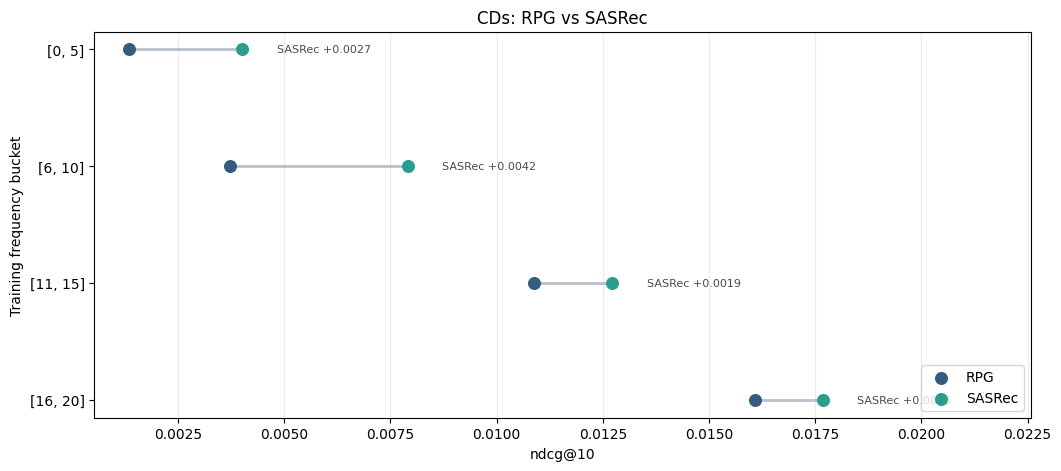

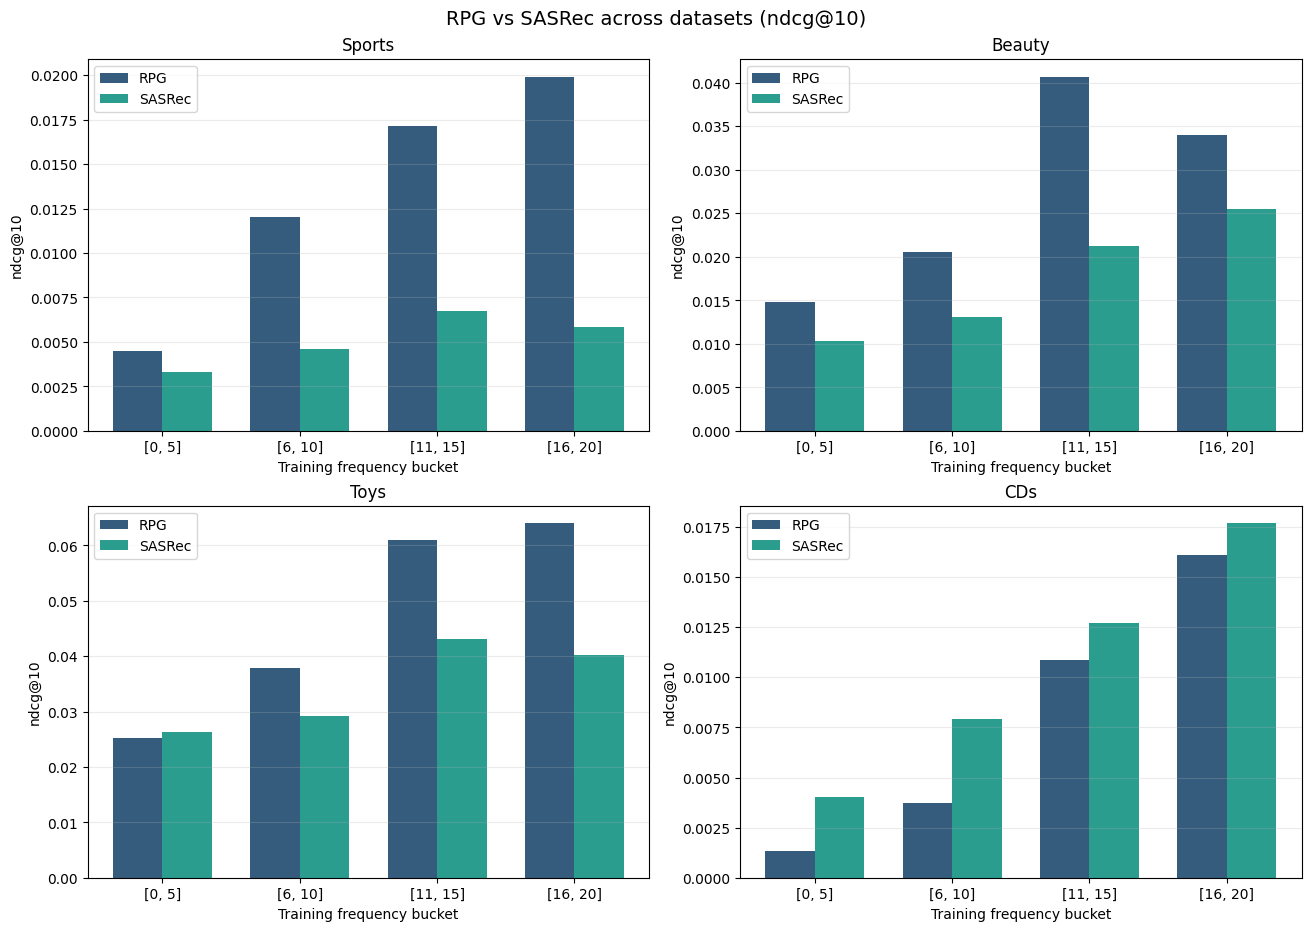

In [8]:
if latest_buckets.empty:
    print("No bucket-level rows available.")
else:
    compare = latest_buckets[
        (latest_buckets["track_label"] == "released README")
        & (latest_buckets["model"].isin(["RPG", "SASRec"]))
    ].copy()

    complete_pairs = (
        compare.groupby(["dataset", "bucket_range"])["model"]
        .nunique()
        .reset_index(name="n_models")
    )
    complete_pairs = complete_pairs[complete_pairs["n_models"] == 2][["dataset", "bucket_range"]]
    compare = compare.merge(complete_pairs, on=["dataset", "bucket_range"], how="inner")

    if compare.empty:
        print("No released README bucket rows are available for both RPG and SASRec.")
    else:
        bucket_order = (
            compare[["bucket_range", "bucket_min_count"]]
            .drop_duplicates()
            .sort_values("bucket_min_count")["bucket_range"]
            .tolist()
        )
        dataset_order = [name for name in DATASET_ORDER if name in set(compare["dataset"])]
        if not dataset_order:
            dataset_order = sorted(set(compare["dataset"]))

        wide = (
            compare.pivot_table(
                index=["dataset", "bucket_range", "bucket_min_count"],
                columns="model",
                values=PRIMARY_METRIC,
                aggfunc="first",
            )
            .reset_index()
        )
        wide = wide.dropna(subset=["RPG", "SASRec"]).copy()
        wide["gap_rpg_minus_sasrec"] = wide["RPG"] - wide["SASRec"]

        bucket_rank = {bucket: idx for idx, bucket in enumerate(bucket_order)}
        rendered_any = False
        for dataset in dataset_order:
            dataset_rows = wide[wide["dataset"] == dataset].copy()
            if dataset_rows.empty:
                continue
            dataset_rows["bucket_rank"] = dataset_rows["bucket_range"].map(bucket_rank)
            dataset_rows = dataset_rows.sort_values("bucket_rank").drop(columns="bucket_rank")
            dataset_rows["y"] = np.arange(len(dataset_rows))[::-1]

            metric_values = dataset_rows[["RPG", "SASRec"]].to_numpy(dtype=float)
            x_min = float(np.nanmin(metric_values))
            x_max = float(np.nanmax(metric_values))
            x_span = max(x_max - x_min, 0.001)
            text_pad = max(0.0005, 0.05 * x_span)
            fig_height = max(4.2, 0.8 * len(dataset_rows) + 1.4)
            fig, ax = plt.subplots(figsize=(10.5, fig_height), constrained_layout=True)

            for render_index, (_, row) in enumerate(dataset_rows.iterrows()):
                y = row["y"]
                ax.plot([row["SASRec"], row["RPG"]], [y, y], color="#B8C1CC", linewidth=2, zorder=1)
                ax.scatter(row["RPG"], y, s=70, color="#355C7D", label="RPG" if render_index == 0 else None, zorder=3)
                ax.scatter(row["SASRec"], y, s=70, color="#2A9D8F", label="SASRec" if render_index == 0 else None, zorder=3)

                gap = row["gap_rpg_minus_sasrec"]
                if gap > 0:
                    gap_label = f"RPG +{gap:.4f}"
                elif gap < 0:
                    gap_label = f"SASRec +{abs(gap):.4f}"
                else:
                    gap_label = "tie"
                x_text = max(row["RPG"], row["SASRec"]) + text_pad
                ax.text(x_text, y, gap_label, va="center", fontsize=8, color="#4A4A4A")

            ax.set_yticks(dataset_rows["y"])
            ax.set_yticklabels(dataset_rows["bucket_range"])
            ax.set_xlabel(PRIMARY_METRIC)
            ax.set_ylabel("Training frequency bucket")
            ax.set_title(f"{dataset}: RPG vs SASRec")
            ax.grid(axis="x", alpha=0.25)
            ax.set_xlim(x_min - 0.05 * x_span, x_max + 0.30 * x_span)
            ax.legend(loc="lower right")
            plt.show()
            rendered_any = True

        if not rendered_any:
            print("No comparable rows are available for the dataset summary plots.")
        else:
            panel_count = len(dataset_order)
            ncols = 2
            nrows = int(np.ceil(panel_count / ncols))
            fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.6 * nrows), constrained_layout=True)
            axes = np.atleast_1d(axes).ravel()
            bar_width = 0.36
            x = np.arange(len(bucket_order), dtype=float)

            for axis, dataset in zip(axes, dataset_order):
                dataset_rows = wide[wide["dataset"] == dataset].copy()
                dataset_rows["bucket_rank"] = dataset_rows["bucket_range"].map(bucket_rank)
                dataset_rows = dataset_rows.sort_values("bucket_rank")
                if dataset_rows.empty:
                    axis.set_visible(False)
                    continue

                axis.bar(x - bar_width / 2, dataset_rows["RPG"], width=bar_width, color="#355C7D", label="RPG")
                axis.bar(x + bar_width / 2, dataset_rows["SASRec"], width=bar_width, color="#2A9D8F", label="SASRec")
                axis.set_title(dataset)
                axis.set_xticks(x)
                axis.set_xticklabels(bucket_order)
                axis.set_xlabel("Training frequency bucket")
                axis.set_ylabel(PRIMARY_METRIC)
                axis.grid(axis="y", alpha=0.25)
                axis.set_ylim(bottom=0)
                axis.legend(loc="upper left")

            for axis in axes[panel_count:]:
                axis.set_visible(False)

            fig.suptitle(f"RPG vs SASRec across datasets ({PRIMARY_METRIC})", fontsize=14)
            plt.show()
